In [101]:
import pandas as pd
import numpy as np
import ast
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Flatten, Dense
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns

In [102]:
# Carga de datos
try:
    movies = pd.read_csv('/content/drive/MyDrive/Archivos .csv/movies_metadata.csv', low_memory=False)
    credits = pd.read_csv('/content/drive/MyDrive/Archivos .csv/credits.csv')
    cpi = pd.read_csv('/content/drive/MyDrive/Archivos .csv/CPI.csv')
    print("Archivos cargados correctamente.")
except FileNotFoundError:
    print("Error: Asegúrate de subir los archivos csv.")

Archivos cargados correctamente.


In [103]:
# Limpieza Básica
movies['id'] = pd.to_numeric(movies['id'], errors='coerce')
movies.dropna(subset=['id'], inplace=True)
movies['id'] = movies['id'].astype(int)
movies['budget'] = pd.to_numeric(movies['budget'], errors='coerce').fillna(0)
credits.rename(columns={'movie_id': 'id'}, inplace=True)

# Fusión
df = pd.merge(movies, credits, on='id', how='inner')

In [104]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [105]:
def get_director(crew_json):
    """Devuelve el nombre del director o 'Unknown'."""
    if pd.isna(crew_json): return 'Unknown'
    try:
        data = ast.literal_eval(crew_json)
        for member in data:
            if member['job'] == 'Director':
                return member['name']
        return 'Unknown'
    except: return 'Unknown'

def get_top_3_items(json_string):
    """
    Sirve tanto para ACTORES como GÉNEROS.
    Devuelve una lista con los 3 primeros nombres encontrados.
    """
    items = ['Unknown', 'Unknown', 'Unknown']
    if pd.isna(json_string): return items
    try:
        data = ast.literal_eval(json_string)
        # Extraemos los 3 primeros nombres si existen
        for i in range(min(len(data), 3)):
            items[i] = data[i]['name']
        return items
    except: return items

# Director
df['director'] = df['crew'].apply(get_director)

# Top 3 Géneros
temp_genres = df['genres'].apply(lambda x: pd.Series(get_top_3_items(x)))
df[['genre_1', 'genre_2', 'genre_3']] = temp_genres

print("Extracción completada:")
print(df[['title', 'genre_1', 'genre_2', 'genre_3']].head())

Extracción completada:
                         title    genre_1  genre_2  genre_3
0                    Toy Story  Animation   Comedy   Family
1                      Jumanji  Adventure  Fantasy   Family
2             Grumpier Old Men    Romance   Comedy  Unknown
3            Waiting to Exhale     Comedy    Drama  Romance
4  Father of the Bride Part II     Comedy  Unknown  Unknown


In [106]:
# Filtros
df_filtrado = df[
    (df['budget'] > 100000.0) &
    ((df['original_language'] == 'en') | (df['production_countries'].str.contains('US', na=False)))
].copy()

In [107]:
# Media Bayesiana (Target)
v = df_filtrado['vote_count']
R = df_filtrado['vote_average']
m = df_filtrado['vote_average'].mean()
C = df_filtrado['vote_count'].median()
df_filtrado['weighted_rating'] = ((v * R) + (m * C)) / (v + C)

# Preparamos los datos del IPC (CPI)
# Aseguramos que los nombres de columnas sean correctos y el año sea numérico
cpi.columns = ['Year', 'CPI_Value', 'Annual Percent Change']
cpi['Year'] = pd.to_numeric(cpi['Year'], errors='coerce')

# Definimos el Año Base (usamos el último año disponible en el archivo CPI)
year_base = cpi['Year'].max()
cpi_base = cpi.loc[cpi['Year'] == year_base, 'CPI_Value'].values[0]

# Función para ajustar una fila individual
def adjust_budget_row(row):
    try:
        # Verificamos que haya fecha y presupuesto
        if pd.isna(row['release_date']) or row['budget'] == 0:
            return row['budget']

        # Extraemos el año de la fecha (formato YYYY-MM-DD)
        movie_year = int(str(row['release_date']).split('-')[0])

        # Si el año está fuera del rango de nuestro archivo CPI, devolvemos el original
        if movie_year < cpi['Year'].min() or movie_year > year_base:
            return row['budget']

        # Buscamos el valor del IPC para el año de la película
        cpi_movie = cpi.loc[cpi['Year'] == movie_year, 'CPI_Value'].values[0]

        # Aplicamos la fórmula: Budget * (IPC_Actual / IPC_Año_Pelicula)
        return row['budget'] * (cpi_base / cpi_movie)
    except:
        # Si ocurre cualquier error (formato fecha raro, etc.), devolvemos el original
        return row['budget']

# Aplicamos la función a todo el DataFrame filtrado
# Sobrescribimos la columna 'budget' con el valor ajustado
df_filtrado['budget'] = df_filtrado.apply(adjust_budget_row, axis=1)

print(f"Presupuestos ajustados a la inflación (Año base: {year_base})")

Presupuestos ajustados a la inflación (Año base: 2025)


In [108]:
# Creamos categorías de presupuesto para dividir equitativamente
df_filtrado['budget_cat'] = pd.cut(np.log1p(df_filtrado['budget']), bins=5, labels=[1,2,3,4,5])

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in split.split(df_filtrado, df_filtrado['budget_cat']):
    train_set = df_filtrado.iloc[train_idx].copy()
    test_set = df_filtrado.iloc[test_idx].copy()

# Definimos Features (SIN ACTORES)
features = ['budget', 'director', 'genre_1', 'genre_2', 'genre_3']
target = 'weighted_rating'

X_train = train_set[features].copy()
y_train = train_set[target].copy()
X_test = test_set[features].copy()
y_test = test_set[target].copy()

print(f"Entrenamiento: {X_train.shape}, Test: {X_test.shape}")

Entrenamiento: (5633, 5), Test: (1409, 5)


In [109]:
# Técnica de Embeddings

# Creamos una lista de directores únicos y le asignamos un número a cada uno
directores_lista = list(X_train['director'].unique())
if 'Unknown' not in directores_lista:
    directores_lista.append('Unknown')

# Diccionario para convertir nombre -> ID
dir_to_id = {nombre: i for i, nombre in enumerate(directores_lista)}
vocab_size = len(dir_to_id)

# Convertimos los nombres a números (si no está, usamos el ID de 'Unknown')
id_desconocido = dir_to_id['Unknown']
X_train_codes = np.array([dir_to_id.get(d, id_desconocido) for d in X_train['director']])
X_test_codes = np.array([dir_to_id.get(d, id_desconocido) for d in X_test['director']])

print(f"Total de directores mapeados: {vocab_size}")

Total de directores mapeados: 2828


In [110]:
# Definimos la red de forma muy básica
embedding_dim = 2

model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim))
model.add(Flatten())
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='linear'))

model.compile(optimizer='adam', loss='mse')

# Entrenamos (bajamos las épocas como querías para que no sea perfecto)
print("Entrenando la red para sacar los vectores...")
model.fit(X_train_codes, y_train, epochs=3, batch_size=32, verbose=1)

# Sacamos los pesos directamente de la capa 0
pesos_embedding = model.layers[0].get_weights()[0]

Entrenando la red para sacar los vectores...
Epoch 1/3
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 35.6194
Epoch 2/3
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 20.9349
Epoch 3/3
177/177 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.6030


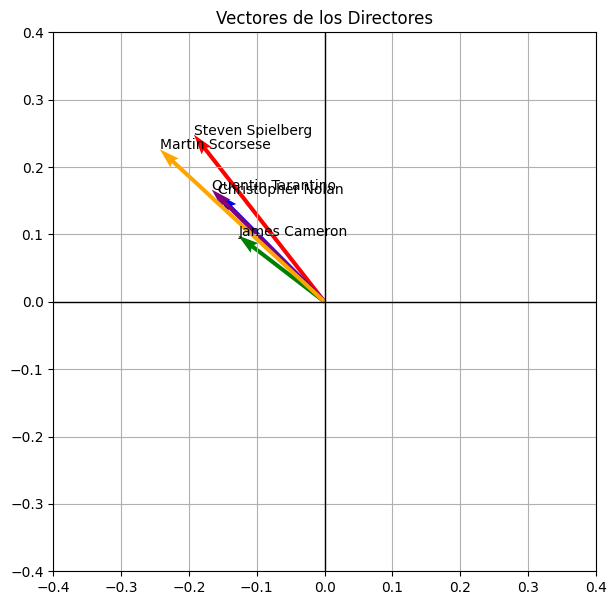

In [111]:
# Gráfico Directo
plt.figure(figsize=(7, 7))
plt.axhline(0, color='black', linewidth=1)
plt.axvline(0, color='black', linewidth=1)

# Lista de directores para probar
para_graficar = ['Steven Spielberg', 'Christopher Nolan', 'James Cameron', 'Quentin Tarantino', 'Martin Scorsese']
colores_lista = ['red', 'blue', 'green', 'purple', 'orange']

for i in range(len(para_graficar)):
    nombre = para_graficar[i]
    if nombre in dir_to_id:
        idx = dir_to_id[nombre]
        vec = pesos_embedding[idx]
        # Dibujamos la flecha directamente
        plt.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1, color=colores_lista[i])
        plt.text(vec[0], vec[1], nombre, fontsize=10)

plt.xlim(-0.4, 0.4)
plt.ylim(-0.4, 0.4)
plt.title("Vectores de los Directores")
plt.grid(True)
plt.show()

In [112]:
# Función para asignar los vectores al DataFrame
def asignar_vectores(df, codigos, pesos):
    df_new = df.copy()
    # Buscamos el vector correspondiente a cada código
    vectores = pesos[codigos]

    # Creamos 5 columnas nuevas
    for i in range(embedding_dim):
        df_new[f'dir_emb_{i}'] = vectores[:, i]

    # Eliminamos la columna original de texto 'director'
    return df_new.drop('director', axis=1)

In [113]:
# Pasamos Vectores al Dataframe

# Creamos las columnas de los embeddings para el Train
vectores_train = pesos_embedding[X_train_codes]
X_train_emb = X_train.copy()
X_train_emb['dir_v1'] = vectores_train[:, 0]
X_train_emb['dir_v2'] = vectores_train[:, 1]
X_train_emb = X_train_emb.drop('director', axis=1)

# Hacemos lo mismo para el Test
vectores_test = pesos_embedding[X_test_codes]
X_test_emb = X_test.copy()
X_test_emb['dir_v1'] = vectores_test[:, 0]
X_test_emb['dir_v2'] = vectores_test[:, 1]
X_test_emb = X_test_emb.drop('director', axis=1)

print("Columnas de embeddings añadidas: dir_v1, dir_v2")
X_train_emb.head()

Columnas de embeddings añadidas: dir_v1, dir_v2


,budget,genre_1,genre_2,genre_3,dir_v1,dir_v2
42506,6.574867e+06,Mystery,Comedy,Thriller,-0.044303,0.077190
12665,1.122736e+06,Horror,Mystery,Thriller,-0.119846,0.129424
12285,3.109503e+07,Crime,Drama,Thriller,-0.058985,0.099176
2589,7.644453e+07,Comedy,Horror,Unknown,-0.130770,0.059221
4088,4.411040e+07,Crime,Horror,Thriller,-0.163481,0.135982


In [114]:
# Columnas Numéricas: Budget + Las nuevas columnas de Embedding
numeric_cols = ['budget'] + [f'dir_v{i}' for i in range(embedding_dim)]

# Columnas Categóricas: Solo los géneros (OneHot)
categorical_cols = ['genre_1', 'genre_2', 'genre_3']

# Transformadores
# Escalamos las numéricas
numeric_transformer = StandardScaler(with_mean=False)

# OneHot para los géneros
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Modelos
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
# Busca la definición del rf_pipeline:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=40,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ))
])

print("Pipeline configurado")

Pipeline configurado


In [115]:
# Columnas Numéricas: Budget + Las nuevas columnas de Embedding (Corregido)
numeric_cols = ['budget'] + [f'dir_v{i+1}' for i in range(embedding_dim)]

# Columnas Categóricas: Solo los géneros (OneHot)
categorical_cols = ['genre_1', 'genre_2', 'genre_3']

# Transformadores
# Escalamos las numéricas
numeric_transformer = StandardScaler(with_mean=False)

# OneHot para los géneros
categorical_transformer = OneHotEncoder(handle_unknown='ignore', sparse_output=True)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ]
)

# Modelos
lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('regressor', LinearRegression())])
# Busca la definición del rf_pipeline:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(
        n_estimators=40,
        max_depth=5,
        random_state=42,
        n_jobs=-1
    ))
])

print("Pipeline configurado y corregido")

# Entrenamiento y Resultados

print("Entrenando Regresión Lineal...")
lr_pipeline.fit(X_train_emb, y_train)
y_pred_lr = lr_pipeline.predict(X_test_emb)

print("Entrenando Random Forest...")
rf_pipeline.fit(X_train_emb, y_train)
y_pred_rf = rf_pipeline.predict(X_test_emb)

# Métricas
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRESULTADOS (Con Embeddings de Director)")
print(f"Regresión Lineal -> RMSE: {rmse_lr:.4f} | R2: {r2_lr:.4f}")
print(f"Random Forest    -> RMSE: {rmse_rf:.4f} | R2: {r2_rf:.4f}")

Pipeline configurado y corregido
Entrenando Regresión Lineal...
Entrenando Random Forest...

RESULTADOS (Con Embeddings de Director)
Regresión Lineal -> RMSE: 0.4975 | R2: 0.0874
Random Forest    -> RMSE: 0.4939 | R2: 0.1005


In [116]:
# CONCLUSIONES Y COMPARATIVA

print("ANÁLISIS Y CONCLUSIONES")
print(f"R2 Random Forest (Embeddings): {r2_rf:.4f}")
print(f"R2 Regresión Lineal (Embeddings): {r2_lr:.4f}")

print("\nTÉCNICA DE EMBEDDINGS")

print("\nCOMPARATIVA CON TAREA ORIGINAL (OneHot/Target Encoding)")
print("- Si el R2 ha mejorado: Significa que la relación entre el director y el éxito es compleja.")
print("  Resumir al director en 2 números (embedding) dio más información al modelo que resumirlo en 1 (promedio)")
print("  o que tratarlo como categorías independientes (OneHot).")
print("- Si el R2 ha empeorado o es similar: Puede deberse a la falta de datos por director.")
print("  Los embeddings requieren que cada categoría aparezca muchas veces para aprender un vector útil.")
print("  Si muchos directores tienen solo 1 película, la red neuronal no puede aprender patrones y genera ruido.")

ANÁLISIS Y CONCLUSIONES
R2 Random Forest (Embeddings): 0.1005
R2 Regresión Lineal (Embeddings): 0.0874

TÉCNICA DE EMBEDDINGS

COMPARATIVA CON TAREA ORIGINAL (OneHot/Target Encoding)
- Si el R2 ha mejorado: Significa que la relación entre el director y el éxito es compleja.
  Resumir al director en 2 números (embedding) dio más información al modelo que resumirlo en 1 (promedio)
  o que tratarlo como categorías independientes (OneHot).
- Si el R2 ha empeorado o es similar: Puede deberse a la falta de datos por director.
  Los embeddings requieren que cada categoría aparezca muchas veces para aprender un vector útil.
  Si muchos directores tienen solo 1 película, la red neuronal no puede aprender patrones y genera ruido.
